# Baseline SNN Training on CIFAR10-DVS

This notebook trains the first baseline spiking neural network on CIFAR10-DVS using the current default preprocessing choice:

- `n_time_bins = 10`
- two polarity channels
- frame normalization enabled

## Goals

- build the baseline event-to-frame dataset pipeline
- create train, validation, and test splits
- train the baseline convolutional SNN
- save the best checkpoint
- inspect training curves and final evaluation metrics

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

PROJECT_ROOT

PosixPath('/home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import ConfusionMatrixDisplay
from torch import nn

from snn_cifar10dvs.config import CIFAR10DVSConfig, ProjectPaths
from snn_cifar10dvs.data import build_dataloaders, create_dataset_splits, load_cifar10dvs
from snn_cifar10dvs.evaluate import collect_predictions, summarize_classification
from snn_cifar10dvs.models import BaselineConvSNN, BaselineSNNConfig
from snn_cifar10dvs.preprocessing import FrameTransformConfig, build_frame_transform
from snn_cifar10dvs.train import fit
from snn_cifar10dvs.utils import count_parameters, get_device, set_seed


## Experiment Configuration

In [3]:
paths = ProjectPaths()
dataset_config = CIFAR10DVSConfig(
    batch_size=8,
    n_time_bins=10,
)
model_config = BaselineSNNConfig(
    input_channels=2,
    num_classes=dataset_config.num_classes,
)

learning_rate = 1e-3
num_epochs = 5
checkpoint_path = paths.checkpoints_dir / "baseline_conv_snn.pt"

set_seed(dataset_config.random_seed)
device = get_device()
print("device:", device)
print("checkpoint path:", checkpoint_path)

device: cuda
checkpoint path: /home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject/outputs/checkpoints/baseline_conv_snn.pt


## Dataset and Dataloaders

## Device Diagnostics

In [4]:
print("torch.cuda.is_available():", torch.cuda.is_available())
print("torch.cuda.device_count():", torch.cuda.device_count())

if torch.cuda.is_available():
    print("cuda device name:", torch.cuda.get_device_name(0))
else:
    print("cuda device name: CPU only")

print("resolved training device:", device)

torch.cuda.is_available(): True
torch.cuda.device_count(): 1
cuda device name: NVIDIA GeForce RTX 4060 Laptop GPU
resolved training device: cuda


In [5]:
frame_transform = build_frame_transform(
    FrameTransformConfig(
        sensor_size=dataset_config.sensor_size,
        n_time_bins=dataset_config.n_time_bins,
        normalize=True,
    )
)

framed_dataset = load_cifar10dvs(paths=paths, transform=frame_transform)
splits = create_dataset_splits(framed_dataset, config=dataset_config)
dataloaders = build_dataloaders(
    splits=splits,
    batch_size=dataset_config.batch_size,
    num_workers=dataset_config.num_workers,
    pin_memory=(device.type == "cuda"),
)

class_names = list(framed_dataset.classes)
print("dataset size:", len(framed_dataset))
print("train size:", len(splits.train))
print("validation size:", len(splits.validation))
print("test size:", len(splits.test))

dataset size: 10000
train size: 7000
validation size: 1500
test size: 1500


In [6]:
example_inputs, example_targets = next(iter(dataloaders["train"]))
print("batch input shape:", tuple(example_inputs.shape))
print("batch target shape:", tuple(example_targets.shape))
print("batch dtype:", example_inputs.dtype)

batch input shape: (8, 10, 2, 128, 128)
batch target shape: (8,)
batch dtype: torch.float32


## Model Setup

In [7]:
model = BaselineConvSNN(model_config).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(model)
print("trainable parameters:", count_parameters(model))

BaselineConvSNN(
  (features): Sequential(
    (0): Conv2d(2, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc_hidden): Linear(in_features=1024, out_features=256, bias=True)
  (lif_hidden): Leaky()
  (fc_out): Linear(in_features=256, out_features=10, bias=True)
  (lif_out): Leaky()
)
trainable parameters: 288922


## Training

In [8]:
history = fit(
    model=model,
    train_loader=dataloaders["train"],
    validation_loader=dataloaders["validation"],
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=num_epochs,
    checkpoint_path=checkpoint_path,
)

history

Train 1/5:   0%|          | 0/875 [00:00<?, ?it/s]

Val 1/5:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1/5 | train_loss=2.1177 | train_acc=0.1966 | val_loss=2.0529 | val_acc=0.2620
Saved improved checkpoint to /home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject/outputs/checkpoints/baseline_conv_snn.pt


Train 2/5:   0%|          | 0/875 [00:00<?, ?it/s]

Val 2/5:   0%|          | 0/188 [00:00<?, ?it/s]

...

Epoch 4/5 | train_loss=1.5226 | train_acc=0.4453 | val_loss=1.5613 | val_acc=0.4413
Saved improved checkpoint to /home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject/outputs/checkpoints/baseline_conv_snn.pt


Train 5/5:   0%|          | 0/875 [00:00<?, ?it/s]

Val 5/5:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 5/5 | train_loss=1.4105 | train_acc=0.4981 | val_loss=1.4620 | val_acc=0.4713
Saved improved checkpoint to /home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject/outputs/checkpoints/baseline_conv_snn.pt


[TrainingEpochResult(epoch=1, train_loss=2.117672582898821, train_accuracy=0.19657142857142856, validation_loss=2.0529196656545, validation_accuracy=0.262),
 TrainingEpochResult(epoch=2, train_loss=1.8351195165770395, train_accuracy=0.3162857142857143, validation_loss=1.7720274772644042, validation_accuracy=0.35533333333333333),
 TrainingEpochResult(epoch=3, train_loss=1.6575071125711713, train_accuracy=0.39785714285714285, validation_loss=1.635867992401123, validation_accuracy=0.4053333333333333),
 TrainingEpochResult(epoch=4, train_loss=1.5226018274171012, train_accuracy=0.4452857142857143, validation_loss=1.5613455034891763, validation_accuracy=0.44133333333333336),
 TrainingEpochResult(epoch=5, train_loss=1.4105033246449061, train_accuracy=0.49814285714285716, validation_loss=1.462048530101776, validation_accuracy=0.4713333333333333)]

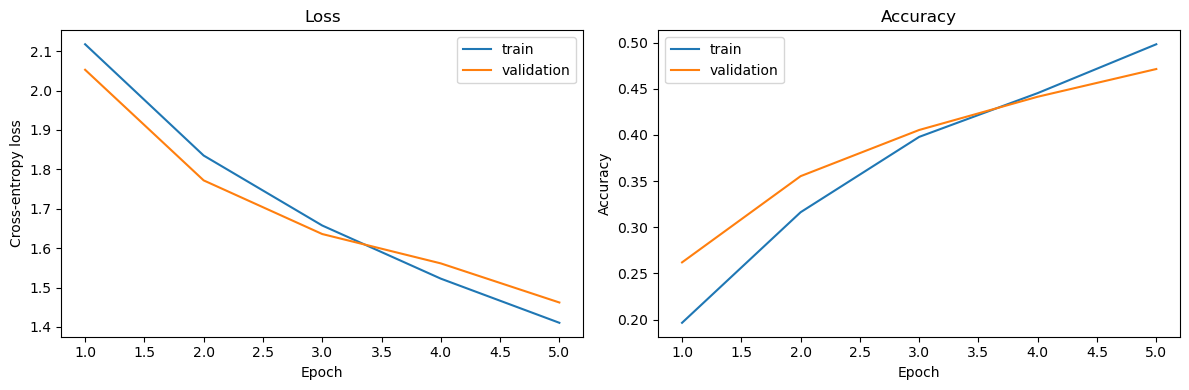

In [9]:
epochs = [entry.epoch for entry in history]
train_loss = [entry.train_loss for entry in history]
train_accuracy = [entry.train_accuracy for entry in history]
validation_loss = [entry.validation_loss for entry in history]
validation_accuracy = [entry.validation_accuracy for entry in history]

figure, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_loss, label="train")
axes[0].plot(epochs, validation_loss, label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend()

axes[1].plot(epochs, train_accuracy, label="train")
axes[1].plot(epochs, validation_accuracy, label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

figure.tight_layout()
plt.show()

## Test Evaluation

In [10]:
evaluation_outputs = collect_predictions(
    model=model,
    dataloader=dataloaders["test"],
    device=device,
)
metrics = summarize_classification(
    evaluation_outputs=evaluation_outputs,
    class_names=class_names,
)

print("test accuracy:", metrics["accuracy"])
metrics["classification_report"]

test accuracy: 0.494


{'airplane': {'precision': 0.3323262839879154,
  'recall': 0.7333333333333333,
  'f1-score': 0.4573804573804574,
  'support': 150.0},
 'automobile': {'precision': 0.6277372262773723,
  'recall': 0.5733333333333334,
  'f1-score': 0.5993031358885017,
  'support': 150.0},
 'bird': {'precision': 0.3412698412698413,
  'recall': 0.2866666666666667,
  'f1-score': 0.3115942028985507,
  'support': 150.0},
 'cat': {'precision': 0.3968253968253968,
  'recall': 0.16666666666666666,
  'f1-score': 0.2347417840375587,
  'support': 150.0},
 'deer': {'precision': 0.425531914893617,
  'recall': 0.4,
  'f1-score': 0.41237113402061853,
  'support': 150.0},
 'dog': {'precision': 0.5088757396449705,
  'recall': 0.5733333333333334,
  'f1-score': 0.5391849529780565,
  'support': 150.0},
 'frog': {'precision': 0.6,
  'recall': 0.56,
  'f1-score': 0.5793103448275863,
  'support': 150.0},
 'horse': {'precision': 0.6896551724137931,
  'recall': 0.5333333333333333,
  'f1-score': 0.6015037593984962,
  'support': 15

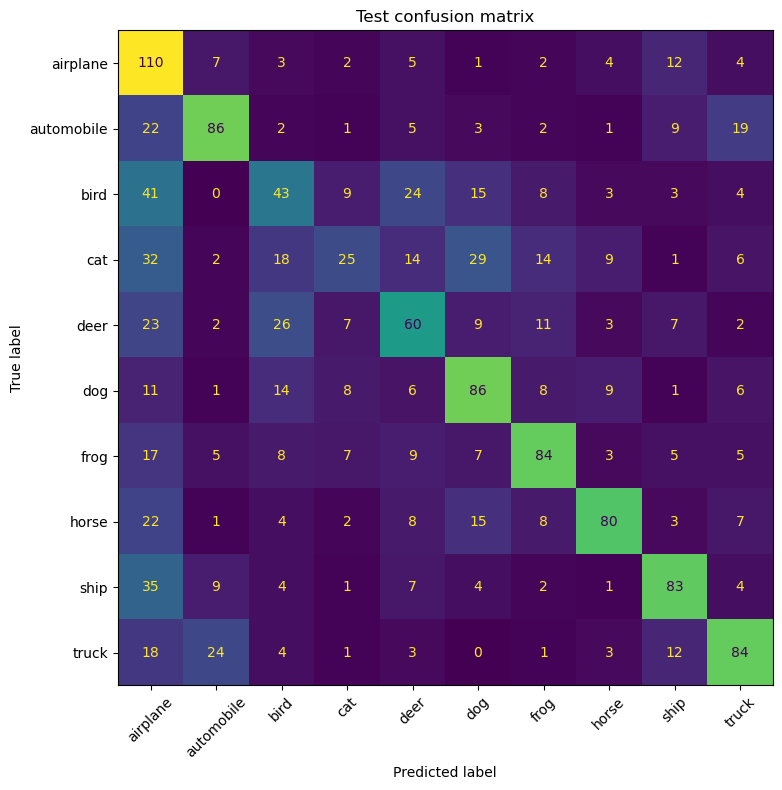

In [11]:
figure, axis = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(
    confusion_matrix=metrics["confusion_matrix"],
    display_labels=class_names,
).plot(ax=axis, xticks_rotation=45, colorbar=False)
axis.set_title("Test confusion matrix")
figure.tight_layout()
plt.show()

## Notes

- This is the first baseline training run, not the final tuned model.
- Once this notebook runs successfully, the next iterations can vary preprocessing, time bins, learning rate, and model size.
- If training is slow on CPU, reduce `num_epochs` or use a smaller exploratory subset for quick checks.